<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/WEEK3(PART2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [3]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


!pip install -U kaggle
# Kaggle authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_db787e8ff274e8431e1bd47cce5d0b5b"

# Download Galaxy Zoo 2 dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p galaxy_raw

# Extract dataset
!unzip -q -o galaxy_raw/galaxy-zoo-2-images.zip -d {RAW_ROOT}

# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}

# Download Hart et al. labels
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 19.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:30<00:00, 109MB/s]



In [4]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)

RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434


In [5]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [6]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [7]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

dataset = ImageFolder(root=DATA_ROOT, transform=transform)

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
num_classes = len(train_ds.dataset.classes)

print("Classes      :", train_ds.dataset.classes)
print("Num_Classes  :", num_classes)



Classes      : ['elliptical', 'spiral', 'spiral_barred']
Num_Classes  : 3


In [8]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
model= GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [10]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
logits=model(images)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")
print(logits.shape)


Total params: 1,054,179
torch.Size([32, 3])


In [11]:
import math
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss=criterion(logits, labels)
print(loss.item(),"vs ln(C)",math.log(num_classes))

1.0989747047424316 vs ln(C) 1.0986122886681098


# STEP-1

In [12]:
@torch.no_grad()                                   # same as wrapping the body in torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()                                   # evaluation mode
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)                    # logits (B, num_classes)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * inputs.size(0)

        preds = outputs.argmax(dim=1)              # predicted class = biggest logit
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

# STEP-2

In [13]:
num_epochs=8
train_losses=[]
val_losses=[]
for epoch in range(num_epochs):
      model.train()
      running=0
      for inputs, targets in train_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          optimizer.zero_grad()
          out=model(inputs)
          loss=criterion(out, targets)
          loss.backward()
          optimizer.step()
          running += loss.item()*inputs.size(0)
      train_losses.append(running/len(train_loader.dataset))
      vl, va = evaluate(model, val_loader, criterion, device)
      val_losses.append(vl)
      print(f"epoch {epoch+1}: train {train_losses[-1]:.3f}  val {vl:.3f}  val_acc {va:.3f}")

epoch 1: train 1.136  val 1.100  val_acc 0.333
epoch 2: train 1.105  val 1.090  val_acc 0.367
epoch 3: train 1.071  val 1.085  val_acc 0.356
epoch 4: train 1.040  val 1.114  val_acc 0.389
epoch 5: train 1.069  val 1.101  val_acc 0.389
epoch 6: train 1.002  val 1.052  val_acc 0.389
epoch 7: train 0.963  val 1.121  val_acc 0.367
epoch 8: train 0.937  val 1.102  val_acc 0.444


# STEP-3

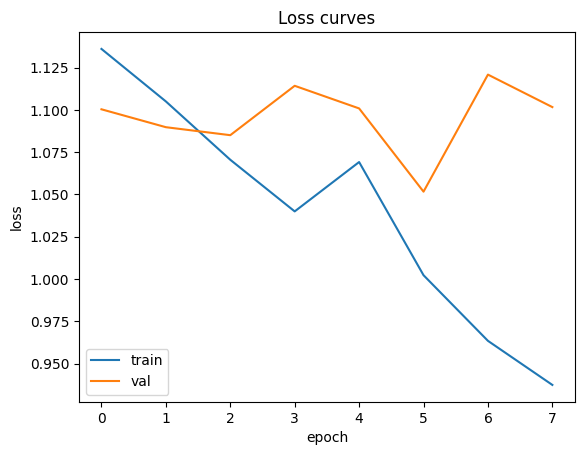

In [14]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss curves")
plt.show()

# STEP-4

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"test accuracy: {test_acc:.3f}")

baseline = 0.433 # logistic regresssion
print(f"beat baseline by {test_acc - baseline:+.3f}")



test accuracy: 0.422
beat baseline by -0.011


# STEP-5

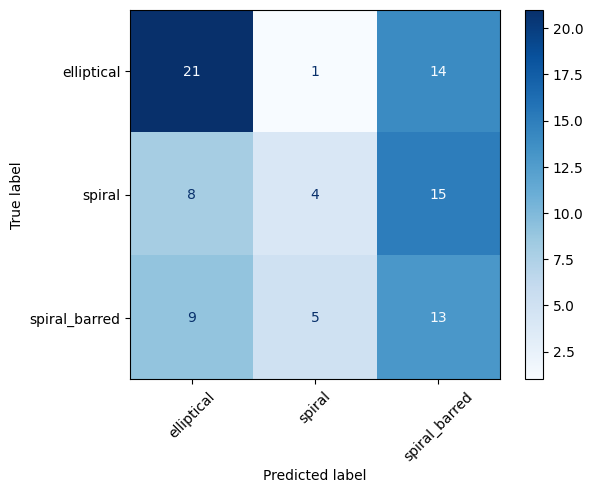

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
model.eval()
all_preds=[]; all_labels=[]
with torch.no_grad():
      for inputs, targets in test_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          preds = model(inputs).argmax(dim=1).cpu()
          all_preds.append(preds); all_labels.append(targets)
y_pred = torch.cat(all_preds).cpu().numpy()
y_true = torch.cat(all_labels).cpu().numpy()
cm = confusion_matrix(y_true, y_pred)
D=ConfusionMatrixDisplay(cm, display_labels=test_ds.dataset.classes)
D.plot(cmap='Blues', xticks_rotation=45)
plt.show()

# step-6

In [17]:
print(classification_report(y_true, y_pred, target_names=test_ds.dataset.classes))

               precision    recall  f1-score   support

   elliptical       0.55      0.58      0.57        36
       spiral       0.40      0.15      0.22        27
spiral_barred       0.31      0.48      0.38        27

     accuracy                           0.42        90
    macro avg       0.42      0.40      0.39        90
 weighted avg       0.43      0.42      0.40        90



# STEP-7

In [18]:

torch.save(model.state_dict(), 'galaxy_model.pth')
loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load('galaxy_model.pth', map_location=device)); loaded.eval()
_ , acc2 = evaluate(loaded, test_loader, criterion, device)
assert abs(acc2 - test_acc) < 1e-6; print('round-trip verified:', acc2)



round-trip verified: 0.4222222222222222


# STEP-8

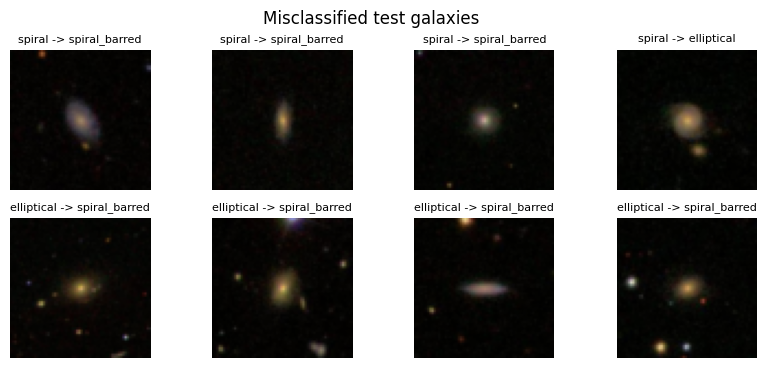

In [19]:
model.eval()
shown = 0
plt.figure(figsize=(10, 4))
with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        for img, t, p in zip(inputs, targets, preds):
            if t != p and shown < 8:
                shown += 1
                ax = plt.subplot(2, 4, shown)
                ax.imshow((img * 0.5 + 0.5).permute(1, 2, 0).numpy())
                ax.set_title(f"{test_ds.dataset.classes[t]} -> {test_ds.dataset.classes[p]}", fontsize=8)
                ax.axis("off")
        if shown >= 8:
            break
plt.suptitle("Misclassified test galaxies")
plt.show()



# REFLECTION

1. The CNN's accuracy is 0.011 lower than the best baseline model from Week 2, which was Logistic Regression. *But when I ran the Week 2 (Part 1) notebook again, I got a different accuracy. I'm not sure why the accuracy changed, so for now I've written the answer according to the latest result. I'll try again to find where I went wrong.*

2.

3. As in previous weeks, the model most commonly confuses *spiral* and *spiral_barred*. This is due to both the inherent similarity b/w these classes and the model's limitations.

4. It's important because it verifies that the reloaded model produces the same results as the original model, confirming that the model was saved and restored correctly.
